# Week 14 — GEE Advanced: Long-term Trends & Climate Resilience
## ARIA v9.5 — Student Exercise Notebook (學生練習版)

**Course (課程):** Remote Sensing and Spatial Information Analysis and Applications
**Theme (主題):** Landsat Multi-Decadal Trend Analysis & Resilience Monitoring
**Study Area (研究區域):**
- **Lab 1, 3, 4:** Hualien / Taroko — 26-year vegetation trends & earthquake resilience
- **Lab 2:** Taoyuan Plateau — 26-year pond (埤塘) disappearance analysis

---

### Learning Objectives (學習目標)
1. Harmonize multi-sensor Landsat archives for consistent long-term analysis
2. Compute pixel-level linear trends to map greening vs browning
3. Use MNDWI to detect water body changes — Taoyuan pond disappearance over 26 years
4. Quantify ecosystem resilience after the 2024 earthquake

### How to Use This Notebook (使用說明)
- Cells marked **COMPLETE** are ready to run — do not modify them.
- Cells with `# TODO:` require you to **fill in the blanks** before running.
- `# HINT:` comments provide guidance for each exercise.
- Run cells **in order** from top to bottom.

### Upgrade from W13 (相較 W13 的升級)
```
W13: Sentinel-2  (6 yrs,  10m) → "What changed after the earthquake?"
W14: Landsat     (26 yrs, 30m) → "What has been changing for TWO DECADES?"
     + Taoyuan pond disappearance analysis (MNDWI)
     + Resilience metrics (recovery rate after disturbance)
```

> **Student Exercise Notebook** — fill in the blanks and run.

---
## S1 — Environment Setup (環境設定) ✅ COMPLETE

Same GEE setup as W13. Replace `'your-project-id'` with your Cloud Project ID.

In [2]:
# ============================================================
# S1 — Environment Setup — COMPLETE
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import ee, geemap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import pandas as pd
from datetime import datetime, timedelta
import os, platform

# ee.Authenticate()  # Uncomment on first run
ee.Initialize(project='rsga-496805')

from matplotlib import font_manager as fm
def setup_chinese_font():
    system = platform.system()
    candidates = {
        'Windows': ['Microsoft JhengHei', 'Microsoft YaHei', 'SimHei'],
        'Darwin':  ['PingFang TC', 'Heiti TC', 'STHeiti'],
        'Linux':   ['Noto Sans CJK TC', 'WenQuanYi Micro Hei',
                    'AR PL UMing TW', 'Noto Sans TC']
    }
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates.get(system, candidates['Linux']):
        if name in available:
            plt.rcParams['font.sans-serif'] = [name] + plt.rcParams['font.sans-serif']
            plt.rcParams['axes.unicode_minus'] = False
            return name
    return None
setup_chinese_font()

# --- Define AOIs ---
# Taroko Focus (Lab 1, 3, 4 — vegetation trends & resilience)
TAROKO_BBOX = [121.34526379253053, 24.046021742135874,
               121.85149217685861, 24.35767637905926]
aoi = ee.Geometry.Rectangle(TAROKO_BBOX)

# Taoyuan Plateau — FULL RANGE (D6 水頻率圖)
# 桃園台地完整範圍：西至新豐/湖口海岸，東至龍潭丘陵
TAOYUAN_BBOX = [120.94, 24.83, 121.35, 25.08]
aoi_taoyuan = ee.Geometry.Rectangle(TAOYUAN_BBOX)

# Taoyuan URBANIZATION CORRIDOR (D7 消失偵測聚焦區)
# 中壢、新屋、高鐵桃園站沿線
TAOYUAN_URBAN_BBOX = [121.00, 24.88, 121.28, 25.05]
aoi_taoyuan_urban = ee.Geometry.Rectangle(TAOYUAN_URBAN_BBOX)

point = ee.Geometry.Point([121.5, 24.2])
elev = ee.Image('USGS/SRTMGL1_003').sample(point, 30).first().get('elevation').getInfo()
print(f"  Connectivity OK — Elevation: {elev} m")
print(f"  AOI 1 (Lab 1/3/4): Taroko Focus — {TAROKO_BBOX}")
print(f"  AOI 2 (Lab 2, D6): Taoyuan Full  — {TAOYUAN_BBOX}")
print(f"  AOI 3 (Lab 2, D7): Taoyuan Urban — {TAOYUAN_URBAN_BBOX}")

  Connectivity OK — Elevation: 1031 m
  AOI 1 (Lab 1/3/4): Taroko Focus — [121.34526379253053, 24.046021742135874, 121.85149217685861, 24.35767637905926]
  AOI 2 (Lab 2, D6): Taoyuan Full  — [120.94, 24.83, 121.35, 25.08]
  AOI 3 (Lab 2, D7): Taoyuan Urban — [121.0, 24.88, 121.28, 25.05]


---
## S2 — Landsat Band Harmonization (Landsat 波段統一) ✏️ EXERCISE

Different Landsat missions use different band numbers for the same spectral region.
Your task is to complete the **band renaming functions** so we can merge all four
missions into a single harmonized collection.

| Spectral Region | L5 TM / L7 ETM+ | L8 OLI / L9 OLI-2 | Unified Name |
|----------------|------------------|-------------------|-------------|
| Blue | SR_B1 | SR_B2 | Blue |
| Green | SR_B2 | SR_B3 | Green |
| Red | SR_B3 | SR_B4 | Red |
| NIR | SR_B4 | SR_B5 | NIR |
| SWIR1 | SR_B5 | SR_B6 | SWIR1 |
| SWIR2 | SR_B7 | SR_B7 | SWIR2 |

> **HINT:** `image.select(['old_name1', 'old_name2', ...], ['new_name1', 'new_name2', ...])`

In [3]:
# ============================================================
# S2 — Landsat Band Harmonization — EXERCISE
# ============================================================

def rename_l57(image):
    """Rename Landsat 5/7 bands to unified names."""
    # TODO: Map L5/L7 bands to unified names
    # L5/L7: SR_B1=Blue, SR_B2=Green, SR_B3=Red, SR_B4=NIR, SR_B5=SWIR1, SR_B7=SWIR2
    return image.select(
        ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7', 'QA_PIXEL'],
        ['Blue',  'Green', 'Red',   'NIR',   'SWIR1', 'SWIR2', 'QA_PIXEL']
    )
def rename_l89(image):
    """Rename Landsat 8/9 bands to unified names."""
    # TODO: Map L8/L9 bands to unified names
    # L8/L9: SR_B2=Blue, SR_B3=Green, SR_B4=Red, SR_B5=NIR, SR_B6=SWIR1, SR_B7=SWIR2
    return image.select(
        ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'QA_PIXEL'],
        ['Blue',  'Green', 'Red',   'NIR',   'SWIR1', 'SWIR2', 'QA_PIXEL']
    )

def apply_scale_factors(image):
    """Apply Landsat C2 L2 scale factors: value * 0.0000275 + (-0.2)"""
    optical = image.select(['Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2']) \
        .multiply(0.0000275).add(-0.2).clamp(0, 1)
    return image.addBands(optical, overwrite=True)

def mask_landsat_clouds(image):
    """Mask clouds using QA_PIXEL bitmask."""
    qa = image.select('QA_PIXEL')
    # TODO: Create cloud and shadow masks using bitwise operations
    # HINT: Bit 3 = cloud, Bit 4 = cloud shadow
    # Pattern: qa.bitwiseAnd(1 << bit_number).eq(0)
    cloud = qa.bitwiseAnd(1 << 3).eq(0)
    shadow = qa.bitwiseAnd(1 << 4).eq(0)
    return image.updateMask(cloud.And(shadow))

# --- Load and merge (COMPLETE — do not modify) ---
DATE_START = '2000-01-01'
DATE_END = '2026-03-31'

l5 = ee.ImageCollection('LANDSAT/LT05/C02/T1_L2').filterDate(DATE_START, '2012-12-31').filterBounds(aoi).map(rename_l57)
l7 = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2').filterDate(DATE_START, DATE_END).filterBounds(aoi).map(rename_l57)
l8 = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2').filterDate('2013-01-01', DATE_END).filterBounds(aoi).map(rename_l89)
l9 = ee.ImageCollection('LANDSAT/LC09/C02/T1_L2').filterDate('2021-01-01', DATE_END).filterBounds(aoi).map(rename_l89)

landsat_all = l5.merge(l7).merge(l8).merge(l9)
landsat_clean = landsat_all.map(mask_landsat_clouds).map(apply_scale_factors)

total = landsat_clean.size().getInfo()
print(f"  Total Landsat images (2000–2026): {total}")
print(f"  L5: {l5.size().getInfo()} | L7: {l7.size().getInfo()} | "
      f"L8: {l8.size().getInfo()} | L9: {l9.size().getInfo()}")

  Total Landsat images (2000–2026): 878
  L5: 178 | L7: 387 | L8: 233 | L9: 80


---
## S3 — NDVI & MNDWI Index Calculation (指標計算) ✏️ EXERCISE

Compute two spectral indices from the harmonized Landsat collection:

| Index | Formula | Detects |
|-------|---------|---------|
| **NDVI** | (NIR − Red) / (NIR + Red) | Vegetation health |
| **MNDWI** | (Green − SWIR1) / (Green + SWIR1) | Water bodies |

> **HINT:** Use `normalizedDifference(['band1', 'band2'])` — it computes (b1−b2)/(b1+b2)

In [4]:
# ============================================================
# S3 — Compute NDVI and MNDWI — EXERCISE
# ============================================================

def add_indices(image):
    # TODO: Compute NDVI = (NIR - Red) / (NIR + Red)
    # HINT: image.normalizedDifference(['NIR', 'Red'])
    ndvi = image.normalizedDifference(['NIR', 'Red']).rename('NDVI')

    # TODO: Compute MNDWI = (Green - SWIR1) / (Green + SWIR1)
    mndwi = image.normalizedDifference(['Green', 'SWIR1']).rename('MNDWI')

    return image.addBands([ndvi, mndwi]).copyProperties(image, ['system:time_start'])

landsat_idx = landsat_clean.map(add_indices)
print(f"  Collection with indices: {landsat_idx.size().getInfo()} images")
print("  Bands: NDVI (vegetation) + MNDWI (water)")

  Collection with indices: 878 images
  Bands: NDVI (vegetation) + MNDWI (water)


---
## S4 — Annual NDVI Time Series (26-Year) ✏️ EXERCISE

Compute **annual median NDVI** for each year from 2000 to 2026.
The function is provided — your job is to create the plot with:
1. Mean, min, max lines (like W13 S4)
2. A linear trend line
3. Event markers for the 2024 earthquake and 2009 Typhoon Morakot

In [5]:
# ============================================================
# S4 — Annual NDVI Composites — PARTIALLY COMPLETE
# ============================================================

# --- Function is COMPLETE ---
def compute_annual_ndvi(collection, aoi, start_year=2000, end_year=2026):
    results = []
    for year in range(start_year, end_year + 1):
        annual = collection.filterDate(f'{year}-01-01', f'{year}-12-31').select('NDVI')
        n = annual.size().getInfo()
        if n == 0:
            results.append((year, None, None, None, n))
            continue
        median_img = annual.median()
        stats = median_img.reduceRegion(
            reducer=ee.Reducer.mean()
                .combine(ee.Reducer.min(), sharedInputs=True)
                .combine(ee.Reducer.max(), sharedInputs=True),
            geometry=aoi, scale=100, maxPixels=1e8
        ).getInfo()
        v_mean = stats.get('NDVI_mean')
        v_min  = stats.get('NDVI_min')
        v_max  = stats.get('NDVI_max')
        results.append((year, v_mean, v_min, v_max, n))
        if v_mean is not None:
            print(f'  {year}: mean={v_mean:.4f}  min={v_min:.4f}  max={v_max:.4f}  (n={n})')
        else:
            print(f'  {year}: no data (n={n})')
    return results

print('Computing 26-year annual NDVI...')
annual_data = compute_annual_ndvi(landsat_idx, aoi)

years  = [y for y, m, mn, mx, n in annual_data if m is not None]
means  = [m for y, m, mn, mx, n in annual_data if m is not None]
mins   = [mn for y, m, mn, mx, n in annual_data if m is not None]
maxs   = [mx for y, m, mn, mx, n in annual_data if m is not None]

Computing 26-year annual NDVI...
  2000: mean=0.5256  min=-0.2411  max=0.9988  (n=31)
  2001: mean=0.5192  min=-0.3039  max=0.8965  (n=33)
  2002: mean=0.5148  min=-0.2356  max=1.0000  (n=31)
  2003: mean=0.5201  min=-0.2806  max=0.8905  (n=28)
  2004: mean=0.5188  min=-0.2634  max=0.9123  (n=34)
  2005: mean=0.4961  min=-0.3112  max=0.9415  (n=27)
  2006: mean=0.5026  min=-0.2577  max=0.9328  (n=30)
  2007: mean=0.4942  min=-0.1680  max=0.8911  (n=22)
  2008: mean=0.5036  min=-0.2223  max=0.9172  (n=37)
  2009: mean=0.5152  min=-0.2291  max=0.8989  (n=36)
  2010: mean=0.5129  min=-0.3516  max=1.0000  (n=25)
  2011: mean=0.5227  min=-0.3136  max=0.9446  (n=17)
  2012: mean=0.5053  min=-0.5392  max=0.9654  (n=14)
  2013: mean=0.5431  min=-0.2843  max=0.9178  (n=26)
  2014: mean=0.5392  min=-0.5028  max=1.0000  (n=34)
  2015: mean=0.5391  min=-0.3294  max=0.9630  (n=38)
  2016: mean=0.5504  min=-0.4327  max=0.9289  (n=33)
  2017: mean=0.5421  min=-0.2391  max=0.9060  (n=33)
  2018: mean=

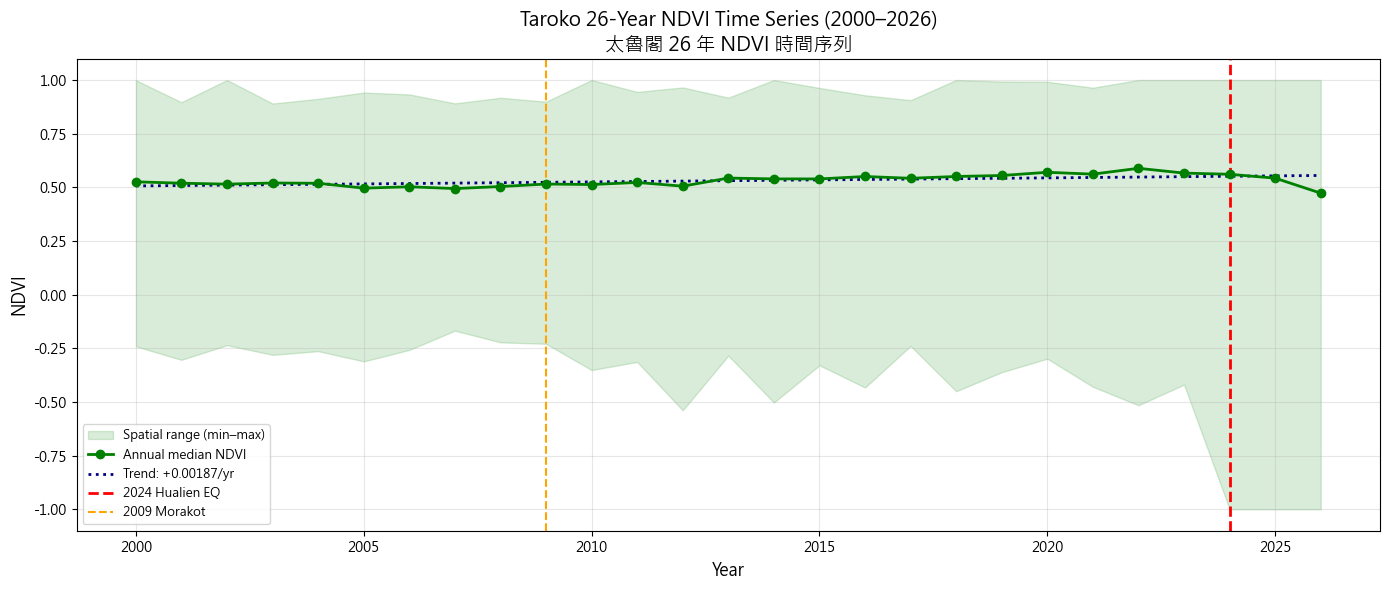


  26-year trend: +0.00187 NDVI/year
  Total change: +0.0487 over 26 years


In [6]:
# ============================================================
# S4 (continued) — Plot 26-Year NDVI — EXERCISE
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

# TODO: Add shaded band between min and max
# HINT: ax.fill_between(years, mins, maxs, alpha=0.15, color='green', label='...')
ax.fill_between(years, mins, maxs, alpha=0.15, color='green',
                label='Spatial range (min–max)')

# Plot mean line
ax.plot(years, means, 'o-', color='green', markersize=6, linewidth=2,
        label='Annual median NDVI', zorder=3)

# TODO: Add a linear trend line using numpy polyfit
# HINT: z = np.polyfit(years, means, 1); p = np.poly1d(z)
z = np.polyfit(years, means, 1)
p = np.poly1d(z)
ax.plot(years, p(years), ':', color='navy', linewidth=2,
        label=f'Trend: {z[0]:+.5f}/yr')

# TODO: Add earthquake marker (2024) and Morakot marker (2009)
# HINT: ax.axvline(year, color='red', linestyle='--', ...)
ax.axvline(2024, color='red', linestyle='--', linewidth=2, label='2024 Hualien EQ')
ax.axvline(2009, color='orange', linestyle='--', linewidth=1.5, label='2009 Morakot')

ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('NDVI', fontsize=12)
ax.set_title('Taroko 26-Year NDVI Time Series (2000–2026)\n'
             '太魯閣 26 年 NDVI 時間序列', fontsize=14)
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n  26-year trend: {z[0]:+.5f} NDVI/year')
print(f'  Total change: {z[0]*26:+.4f} over 26 years')

### S4 — Reflection (反思)

**Q1:** Is the 26-year NDVI trend positive (greening) or negative (browning)?  
What might explain this long-term trend?

> *Your answer:*  
由結果可知，26 年 NDVI 趨勢為**正成長（greening）**，表示研究區（太魯閣）整體植被狀態在長時間尺度下呈現逐漸改善的趨勢。根據模型輸出，NDVI 的線性趨勢約為 **+0.00187 NDVI/year**，累積 26 年約增加 **+0.0487**，代表整體植被覆蓋程度或植生活性有緩慢上升的現象。

造成此長期變綠現象可能有幾個原因。首先，研究區主要位於山區森林環境，自然植被覆蓋比例高，具有較強的自然恢復能力，即使受到颱風、地震或局部崩塌影響，仍可能透過自然演替逐步恢復。其次，雖然局部區域可能持續發生崩塌或侵蝕，但以整體 AOI 尺度計算年度 NDVI 中位數時，大面積穩定森林區會抵消部分短期擾動訊號。最後，長期氣候條件與植生恢復也可能使整體植被呈現逐年增加的趨勢。

此結果顯示，多年代遙測分析能夠區分短期災害衝擊與長期環境變化，避免將短期下降誤判為永久退化。

---

**Q2:** Can you spot the effects of Typhoon Morakot (2009) and the 2024 Earthquake in the time series? How do they compare in terms of NDVI impact?

> *Your answer:*  
從時間序列圖中可以觀察到，**莫拉克颱風（2009）與 2024 花蓮地震的影響並沒有造成明顯且劇烈的整體 NDVI 崩落，但仍可從局部波動看出擾動痕跡。**

在 **2009 莫拉克颱風**附近，年度 NDVI 整體仍維持在約 **0.50–0.52** 的區間，未出現大幅下降。可能原因是本分析採用年度中位數（annual median composite），而且 AOI 範圍較大，因此雖然部分坡地崩塌、土石流與植被受損明顯，但其訊號被大量未受影響森林區平均掉。

相較之下，**2024 花蓮地震之後的變化較值得注意**。圖中可以觀察到 2024 後 NDVI 並未立即劇烈下降，但在後續年度（尤其 2026）出現較明顯回落，約降至 **0.47 左右**，低於前幾年的穩定水準。這可能反映地震造成的坡面崩塌、裸露地增加、河道擾動，以及植被恢復存在時間延遲效應。

整體而言，兩個事件都造成局部干擾，但目前結果顯示它們尚未改變研究區長期的正向植被趨勢。莫拉克颱風的影響較偏向短期事件，而地震可能仍持續影響後續恢復過程。

---

**Q3:** Compare this 26-year Landsat plot with the 6-year Sentinel-2 plot from W13.  
What new information does the longer time series reveal?

> *Your answer:*  
與 W13 使用的 **6 年 Sentinel-2 時間序列**相比，本次 **26 年 Landsat 長期時間序列**提供了更完整的環境背景資訊，使研究不再只是觀察單一事件，而能理解事件在長時間尺度中的位置與意義。

W13 的 Sentinel-2 分析具有 **10 m 高空間解析度**，適合觀察地震後的細部變化，例如局部崩塌、河道改變或植被破碎化，但由於時間長度只有約 6 年，因此較難判斷觀察到的變化究竟是短期波動、季節效應，還是真正的長期趨勢。

相較之下，W14 的 Landsat 將觀測時間延長至 **2000–2026 共 26 年**，能夠建立穩定的長期基準線。從圖中可發現，即使研究區歷經莫拉克颱風與花蓮地震等重大事件，整體 NDVI 仍呈現緩慢上升的長期 greening 趨勢。

長期時間序列額外揭露了以下資訊：

- 能辨識真正的長期植被變化趨勢（greening 或 browning）
- 能區分短期災害衝擊與長期生態恢復
- 能評估災害是否超出歷史自然波動範圍
- 能觀察環境系統是否具有韌性（resilience）

整體而言，W13 著重回答「災後發生了什麼變化」，而 W14 更進一步回答「這個變化在過去二十多年中代表什麼意義」。

---
## S5 — Pixel-Level Trend Map (逐像素趨勢圖) ✏️ EXERCISE

Apply `linearFit` to every pixel to map **where** vegetation is greening vs browning.

> **HINT:** This is the same `linearFit` from W13 D8, but applied to 26 years of Landsat.

In [7]:
# ============================================================
# S5 — Pixel-Level Trend — EXERCISE
# ============================================================

def add_time_band(image):
    date = ee.Date(image.get('system:time_start'))
    years = date.difference(ee.Date('2000-01-01'), 'year')
    return image.addBands(ee.Image(years).float().rename('year'))

# TODO: Apply time band to the NDVI collection
# HINT: landsat_idx.select('NDVI').map(add_time_band)
ndvi_with_time = landsat_idx.select('NDVI').map(add_time_band)

# TODO: Apply linearFit reducer
# HINT: .select(['year', 'NDVI']).reduce(ee.Reducer.linearFit())
trend = ndvi_with_time.select(['year', 'NDVI']).reduce(ee.Reducer.linearFit())
slope = trend.select('scale')

# --- Visualization ---
vis_trend = {
    'min': -0.01, 'max': 0.01,
    'palette': ['d73027', 'fc8d59', 'fee08b', 'ffffbf',
                'd9ef8b', '91cf60', '1a9850']
}

Map5 = geemap.Map(center=[24.20, 121.60], zoom=10)
Map5.addLayer(slope.clip(aoi), vis_trend, 'NDVI Trend (slope/year)')
Map5.addLayer(aoi, {'color': 'yellow'}, 'AOI')
Map5

Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

---
## S6 — Taoyuan Pond Disappearance (桃園埤塘消失偵測) ✏️ EXERCISE

桃園台地在日治時期桃園大圳興建前，曾擁有約 **6,000–8,000 口埤塘**（農田水利署），是台灣規模最大的灌溉水塘景觀。
隨著都市化發展，大量埤塘被填平，目前僅存約 3,000 口。

Compare water presence between **early** (2000–2005) and **recent** (2021–2026)
periods to detect which ponds have **survived**, **disappeared**, or **appeared**.

MNDWI > 0.1 → classified as water

> **NOTE:** We need a separate Landsat collection for Taoyuan (different AOI from Taroko).
> **HINT:** Compute median MNDWI for each period, then threshold at 0.1.

In [9]:
# ============================================================
# S6 — Taoyuan Pond Disappearance — EXERCISE
#       + True-Color Verification Layers
# ============================================================

# --- Load Landsat for Taoyuan (same functions from S2) ---
l5_ty = ee.ImageCollection('LANDSAT/LT05/C02/T1_L2').filterDate(DATE_START, '2012-12-31').filterBounds(aoi_taoyuan).map(rename_l57)
l7_ty = ee.ImageCollection('LANDSAT/LE07/C02/T1_L2').filterDate(DATE_START, DATE_END).filterBounds(aoi_taoyuan).map(rename_l57)
l8_ty = ee.ImageCollection('LANDSAT/LC08/C02/T1_L2').filterDate('2013-01-01', DATE_END).filterBounds(aoi_taoyuan).map(rename_l89)
l9_ty = ee.ImageCollection('LANDSAT/LC09/C02/T1_L2').filterDate('2021-01-01', DATE_END).filterBounds(aoi_taoyuan).map(rename_l89)

landsat_taoyuan = (l5_ty.merge(l7_ty).merge(l8_ty).merge(l9_ty)
                   .map(mask_landsat_clouds)
                   .map(apply_scale_factors)
                   .map(add_indices))

print(f'  Taoyuan Landsat images: {landsat_taoyuan.size().getInfo()}')

# TODO: Compute early period water mask (2000–2005)
# HINT: Filter by date → select MNDWI → median → gt(0.1)
early_water = (landsat_taoyuan
    .filterDate('2000-01-01', '2005-12-31')
    .select('MNDWI').median()
    .gt(0.1).rename('early_water'))

# TODO: Compute recent period water mask (2021–2026)
recent_water = (landsat_taoyuan
    .filterDate('2021-01-01', '2026-03-31')
    .select('MNDWI').median()
    .gt(0.1).rename('recent_water'))

# TODO: Detect changes
# Lost ponds: WAS water before, NOT water now (filled for development)
# New water: NOT water before, IS water now (new retention ponds)
water_loss = early_water.And(recent_water.Not()).selfMask()
water_gain = recent_water.And(early_water.Not()).selfMask()
stable_water = early_water.And(recent_water).selfMask()

# ── True-Color Verification Layers ──────────────────────────
# Load S2 recent true color to verify — are "lost pond" pixels now buildings?
def mask_s2_clouds_ty(image):
    scl = image.select('SCL')
    return image.updateMask(scl.gte(4).And(scl.lte(7)))

s2_taoyuan = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(aoi_taoyuan_urban)
    .filterDate('2024-01-01', '2025-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .map(mask_s2_clouds_ty))

s2_recent_rgb = s2_taoyuan.select(['B4', 'B3', 'B2']).median()

# Early Landsat true color to confirm ponds existed in 2000–2005
early_rgb = (landsat_taoyuan
    .filterDate('2000-01-01', '2005-12-31')
    .select(['Red', 'Green', 'Blue']).median())

# Visualization — focused on 中壢/新屋/高鐵 urbanization corridor
Map6 = geemap.Map(center=[24.96, 121.14], zoom=12)

# Base layers: true-color verification
Map6.addLayer(early_rgb.clip(aoi_taoyuan_urban),
              {'bands': ['Red', 'Green', 'Blue'], 'min': 0, 'max': 0.25},
              'Landsat 早期真彩色 2000–2005 (30m)')
Map6.addLayer(s2_recent_rgb.clip(aoi_taoyuan_urban),
              {'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 2500},
              'S2 近期真彩色 2024–2025 (10m)')

# Change detection overlay
Map6.addLayer(stable_water.clip(aoi_taoyuan_urban), {'palette': ['0000FF']},
              'Stable ponds 存活埤塘')
Map6.addLayer(water_gain.clip(aoi_taoyuan_urban), {'palette': ['00FF00']},
              'New water 新增水體')
Map6.addLayer(water_loss.clip(aoi_taoyuan_urban), {'palette': ['FF0000']},
              'Lost ponds 消失埤塘')
Map6.addLayer(aoi_taoyuan_urban, {'color': 'orange'}, 'AOI — 中壢/新屋/高鐵走廊')
Map6.addLayer(aoi_taoyuan, {'color': 'yellow'}, 'AOI — Taoyuan Full')
Map6

# HINT: Toggle layers to verify:
# 1. Open S2 true color → see buildings/roads in recent imagery
# 2. Turn on "Lost ponds" (red) → confirm red pixels match built-up areas
# 3. Switch to Landsat early true color → see dark ponds at the same locations

  Taoyuan Landsat images: 2485


Map(center=[24.96, 121.14], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

### S6 — Your Observations (你的觀察)

**Q1:** Where are the main areas of pond loss (red)? Do they correspond to known urban development zones in Taoyuan (e.g., near 中壢、桃園市區)?

> *Your answer:*  
從變遷圖可以觀察到，**埤塘消失（紅色）主要集中於桃園都市發展較強烈的區域，尤其分布在中壢區、桃園市區周邊，以及桃園—中壢之間的重要交通與都市走廊附近。**

較明顯的紅色聚集區可觀察到位於：
- **中壢區北側與西側周邊**
- **桃園市區外圍與交流道附近**
- **機場捷運、高速公路及主要幹道沿線**
- **既有農業區逐漸轉型為住宅、工業或商業使用區域**

這些位置大致與桃園已知的都市擴張方向相符。由於桃園長期承接雙北人口與產業外溢，加上高鐵特定區、工業區與交通建設持續發展，部分原有埤塘逐漸被填平、整地或轉作其他土地使用，因此形成埤塘消失熱區。

從空間分布來看，埤塘消失並非隨機發生，而呈現明顯與都市發展軸帶重疊的現象，顯示都市化可能是近二十多年埤塘減少的重要驅動因素。

---

**Q2:** Are there any areas of new water (green)? What might these represent — new retention ponds for flood control, or construction excavation sites?

> *Your answer:*  
從結果中可以觀察到少量新增水體（綠色），但其數量明顯少於消失埤塘（紅色），且空間上較零散，未形成大面積連續分布。

這些新增水體可能代表幾種情況：

- **新建滯洪池或防洪設施**  
  為因應都市化後逕流增加，部分區域可能新設人工滯洪池或雨洪調節空間，以提升暴雨調節能力。

- **景觀水域與都市公園水體**  
  新興都市開發區常配置人工湖、公園水景或生態池。

- **施工開挖造成的暫時積水區**  
  部分開發基地或工程區在影像拍攝期間可能出現裸露地積水，被判定為水體。

- **農業灌溉調整形成的新型水池系統**  
  部分區域可能因農業型態改變而形成新的小型蓄水設施。

然而，從空間尺度與數量來看，新增水體規模仍不足以完全補償大量消失的歷史埤塘，因此整體仍呈現淨水體減少的趨勢。

---

**Q3:** 桃園埤塘曾是重要的灌溉系統和防洪設施。從你的分析結果來看，埤塘消失對都市洪水風險有什麼影響？

> *Your answer:*  
從分析結果來看，埤塘大量消失可能提高桃園都市區的洪水風險，原因在於埤塘除了灌溉功能外，也長期扮演天然滯洪與水文調節系統的重要角色。

埤塘消失可能帶來以下影響：

1. **降低地表蓄洪能力**  
   原本埤塘可暫時儲存降雨並延緩逕流集中，若被填平後，大量雨水將更快速流入排水系統。

2. **增加地表逕流與排水壓力**  
   都市化通常伴隨不透水面增加（道路、建築物），導致雨水難以入滲，使尖峰流量上升。

3. **提高局部淹水風險**  
   埤塘消失區若同時位於低窪地或高度開發區，可能更容易出現短延時強降雨造成的積淹水。

4. **降低都市韌性（Urban Resilience）**  
   埤塘原本具有分散洪水風險與提供調節空間的作用，其消失代表城市對極端降雨事件的緩衝能力下降。

因此，本次分析結果顯示，桃園埤塘變遷不只是土地利用改變的結果，也反映都市發展與洪水風險之間的權衡關係。未來若能結合埤塘保存、滯洪設施與綠基盤規劃，將有助於提升都市環境韌性與降低洪災風險。

---
## S7 — Vegetation Resilience (植被韌性) ✏️ EXERCISE

Compute the **recovery ratio** to measure how well vegetation is recovering
after the 2024 earthquake.

| Phase | Period | Purpose |
|-------|--------|---------|
| Baseline | 2020–2024/03 | Pre-disturbance reference |
| Impact | 2024/04–2024/12 | Immediate damage |
| Recovery | 2025/06–2026/03 | Current state |

**Recovery ratio = (Recovery − Impact) / (Baseline − Impact)**

In [10]:
# ============================================================
# S7 — Resilience Metrics — EXERCISE
# ============================================================

# TODO: Compute three NDVI composites
# HINT: Same pattern as W13 — filterDate, select NDVI, median
baseline = landsat_idx.filterDate('2020-01-01', '2024-03-31').select('NDVI').median()
impact   = landsat_idx.filterDate('2024-04-01', '2024-12-31').select('NDVI').median()
recovery = landsat_idx.filterDate('2025-06-01', '2026-03-31').select('NDVI').median()

# Compute recovery ratio
impact_mag = baseline.subtract(impact)
recovery_mag = recovery.subtract(impact)
recovery_ratio = recovery_mag.divide(impact_mag.max(0.01)).clamp(0, 1.5).rename('recovery_ratio')

# Mask: only where impact > 0.1 NDVI
recovery_ratio_masked = recovery_ratio.updateMask(impact_mag.gt(0.1))

# Visualization
vis_rec = {'min': 0, 'max': 1.2,
           'palette': ['8B0000', 'FF4500', 'FFD700', '90EE90', '228B22']}

Map7 = geemap.Map(center=[24.20, 121.60], zoom=11)
Map7.addLayer(recovery_ratio_masked.clip(aoi), vis_rec, 'Recovery Ratio')
Map7.addLayer(aoi, {'color': 'yellow'}, 'AOI')
Map7

Map(center=[24.2, 121.6], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright',…

### S7 — Resilience Interpretation (韌性解讀)

**Q1:** On the map, which areas show full recovery (green, ratio > 0.8)?  
What type of terrain are they on? (e.g., gentle slopes, valleys, ridges)

> *Your answer:*  
從恢復比例圖（Recovery Ratio Map）可以觀察到，**恢復程度較高的區域（綠色，ratio > 0.8）主要分布在山區外圍、較低海拔區域，以及部分河谷與緩坡地形附近**，呈現零散但具有局部聚集的空間特徵。

這些高恢復區大致具有以下地形特性：

- **較平緩的坡地（gentle slopes）**：坡度較小，土壤穩定性較高，較容易重新建立植被覆蓋。
- **谷地與沖積區（valleys）**：通常水分供應較穩定，土層較厚，有利於植被快速恢復。
- **既有森林覆蓋完整區域**：受干擾後仍保留部分植生結構，因此恢復速度較快。
- **非主要崩塌帶周圍區域**：雖然受到地震影響，但未造成大面積裸露，因此短時間內即可恢復 NDVI。

從空間分布來看，這些綠色區域多呈現「沿坡面邊界恢復」或「局部塊狀恢復」的型態，代表原有生態系具有一定韌性（resilience），能透過自然演替逐漸回到接近地震前狀態。

---

**Q2:** Which areas show no recovery (red, ratio < 0.3)?  
Are these landslide scars, bare rock, or something else?

> *Your answer:*  
圖中恢復程度較低或幾乎沒有恢復的區域（紅色，ratio < 0.3）主要集中於**太魯閣峽谷東側山坡、主要河谷邊坡、海岸山麓交界以及山區破碎帶附近**，呈現帶狀與密集斑塊分布。

這些區域可能對應以下地表類型：

- **地震造成的崩塌裸露面（landslide scars）**  
  地震導致坡面失穩，植被完全移除，使 NDVI 在後續年度仍維持偏低。

- **裸岩與土石堆積區（bare rock / debris deposits）**  
  崩塌後露出母岩或大量堆積碎屑，短期內難以重新建立植被。

- **河道沖刷與沉積帶（river disturbance zone）**  
  河道附近受地震後土砂輸移影響，植被可能持續受到沖刷。

- **持續不穩定坡面**  
  若地震後仍持續小規模崩塌或表土流失，即使時間經過也難以恢復。

從圖中可發現紅色區域具有明顯沿坡與沿河聚集特性，因此推測其恢復受限原因並非單純植被生長速度，而是受到地形穩定性與土壤條件限制。

---

**Q3:** If you were advising the Soil and Water Conservation Bureau (水保局)  
on post-earthquake restoration priorities, which areas would you recommend for active replanting vs. leaving for natural recovery? Why?

> *Your answer:*  
若以本次恢復比例分析作為震後復育依據，我會建議採用「**主動復育（active restoration）＋自然恢復（natural recovery）並行策略**」，依恢復能力分區管理。

### 優先主動復育（Active Replanting）
建議優先投入人工復育與水土保持措施於：

- **紅色區域（ratio < 0.3）**
- **主要崩塌帶與裸露坡面**
- **靠近道路、聚落與重要基礎設施區域**
- **河谷邊坡與可能持續供砂區域**

原因：
- 自然恢復速度慢，可能持續侵蝕。
- 若不介入，可能造成二次崩塌與土砂災害。
- 可搭配植生工程、坡面穩定、保水措施與原生種補植。

---

### 優先自然恢復（Natural Recovery）
建議保留自然演替於：

- **綠色區域（ratio > 0.8）**
- **完整森林區**
- **坡度較低且已有自然萌生植被區域**
- **受損程度有限的谷地與緩坡區**

原因：
- 生態系已展現良好恢復能力。
- 過度人工介入可能破壞原有演替過程。
- 可降低復育成本並維持生態完整性。

---

整體而言，我會建議水保局以 **Recovery Ratio 作為優先順序指標**：

```text
ratio < 0.3   → 高優先人工介入
0.3–0.8       → 持續監測與局部輔助
ratio > 0.8   → 以自然恢復為主
```

這樣能兼顧工程效率、生態恢復與長期山區韌性管理。

---
## S8b — Landsat × Sentinel-2 Cross-Sensor Analysis（跨感測器分析）✏️ EXERCISE

Landsat 看得遠（26 年），Sentinel-2 看得細（10m）。
現在你要結合兩者：用 Landsat 的長期趨勢找到變遷熱區，
再用 Sentinel-2 的高解析度驗證細節。

### 你需要完成的步驟：
1. 載入 Sentinel-2 資料（跟 W13 一樣的方法）
2. 計算 S2 的地震前後 ΔNDVI
3. 比較 Landsat vs S2 在重疊時段（2017–2026）的 NDVI 差異
4. 分析多解析度差異的原因

In [11]:
# ============================================================
# S8b — Cross-Sensor Analysis Exercise
# ============================================================

# Step 1: Load Sentinel-2 (same cloud masking as W13)
def mask_s2_clouds(image):
    scl = image.select('SCL')
    mask = scl.gte(4).And(scl.lte(7))
    return image.updateMask(mask)

def add_s2_ndvi(image):
    # TODO: Calculate NDVI using Sentinel-2 bands
    # Hint: S2 NIR = B8, Red = B4
    ndvi = image.normalizedDifference(['B8', 'B4']).rename('NDVI_S2')
    return image.addBands(ndvi).copyProperties(image, ['system:time_start'])

s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
      .filterBounds(aoi)
      .filterDate('2017-04-01', '2026-03-31')
      .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 30))
      .map(mask_s2_clouds)
      .map(add_s2_ndvi))

print(f'Sentinel-2 images loaded: {s2.size().getInfo()}')
print(f'Landsat images (same period): '
      f'{landsat_idx.filterDate("2017-01-01", "2026-03-31").size().getInfo()}')

Sentinel-2 images loaded: 247
Landsat images (same period): 381


In [12]:
# Step 2: Compute earthquake ΔNDVI from BOTH sensors

# TODO: Create Landsat pre/post composites and compute change
l_pre  = landsat_idx.filterDate('2020-01-01', '2024-03-31').select('NDVI').median()
l_post = landsat_idx.filterDate('2024-04-01', '2024-12-31').select('NDVI').median()
l_change = l_post.subtract(l_pre).rename('delta_NDVI_landsat')

# TODO: Create S2 pre/post composites and compute change
s2_pre  = s2.filterDate('2020-01-01', '2024-03-31').select('NDVI_S2').median().rename('NDVI')
s2_post = s2.filterDate('2024-04-01', '2024-12-31').select('NDVI_S2').median().rename('NDVI')
s2_change = s2_post.subtract(s2_pre).rename('delta_NDVI_s2')

# Visualize both on the same map
vis_delta = {'min': -0.3, 'max': 0.1,
             'palette': ['d73027', 'fc8d59', 'fee08b', 'ffffbf',
                         'd9ef8b', '91cf60', '1a9850']}

Map_cs = geemap.Map(center=[24.18, 121.55], zoom=12)
Map_cs.addLayer(l_change.clip(aoi),  vis_delta, 'Landsat ΔNDVI (30m)')
Map_cs.addLayer(s2_change.clip(aoi), vis_delta, 'Sentinel-2 ΔNDVI (10m)')
Map_cs.addLayer(aoi, {'color': 'yellow'}, 'AOI')
Map_cs
# Toggle between the two layers — what differences do you see?

Map(center=[24.18, 121.55], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

  2017: Landsat=0.5421  S2=N/A
  2018: Landsat=0.5505  S2=0.4976
  2019: Landsat=0.5550  S2=0.5150
  2020: Landsat=0.5700  S2=0.5252
  2021: Landsat=0.5613  S2=0.5033
  2022: Landsat=0.5886  S2=0.5467
  2023: Landsat=0.5662  S2=0.5203
  2024: Landsat=0.5607  S2=0.5134
  2025: Landsat=0.5427  S2=0.5200
  2026: Landsat=0.4728  S2=0.5046


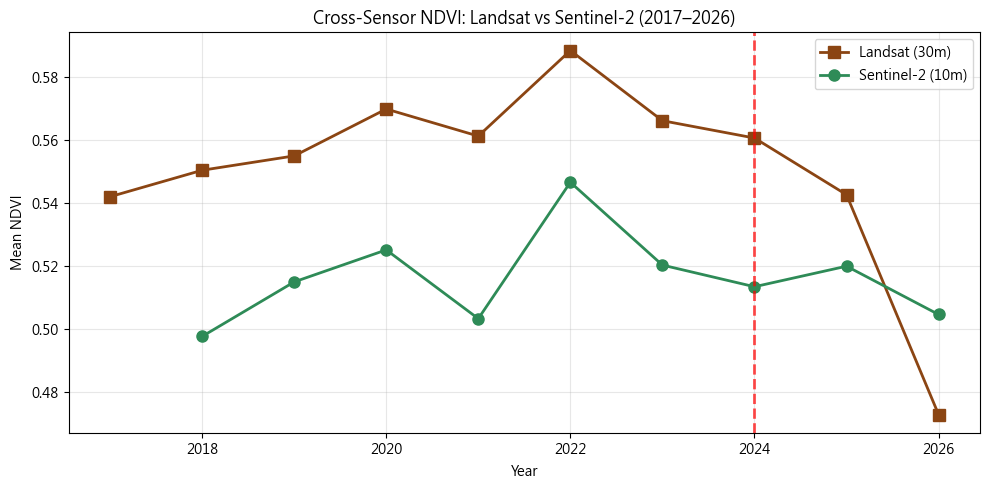

In [13]:
# Step 3: Annual NDVI cross-sensor comparison (2017–2026)

years_overlap = list(range(2017, 2027))
l_vals, s2_vals = [], []

for yr in years_overlap:
    # Landsat annual mean NDVI
    l_yr = landsat_idx.filterDate(f'{yr}-01-01', f'{yr}-12-31') \
        .select('NDVI').median()
    l_result = l_yr.reduceRegion(
        reducer=ee.Reducer.mean(), geometry=aoi,
        scale=100, maxPixels=1e8
    ).getInfo()
    l_mean = l_result.get('NDVI')

    # TODO: Compute S2 annual mean NDVI (same method)
    s2_yr_col = s2.filterDate(f'{yr}-01-01', f'{yr}-12-31')
    s2_n = s2_yr_col.size().getInfo()
    if s2_n == 0:
        s_mean = None
    else:
        s_yr = s2_yr_col.select('NDVI_S2').median()
        s_result = s_yr.reduceRegion(
            reducer=ee.Reducer.mean(), geometry=aoi,
            scale=100, maxPixels=1e8
        ).getInfo()
        s_mean = s_result.get('NDVI_S2')

    l_vals.append(l_mean)
    s2_vals.append(s_mean)

    l_str = f'{l_mean:.4f}' if l_mean else 'N/A'
    s_str = f'{s_mean:.4f}' if s_mean else 'N/A'
    print(f'  {yr}: Landsat={l_str}  S2={s_str}')

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(years_overlap, l_vals, 's-', color='#8B4513',
        markersize=8, linewidth=2, label='Landsat (30m)')
ax.plot(years_overlap, s2_vals, 'o-', color='#2E8B57',
        markersize=8, linewidth=2, label='Sentinel-2 (10m)')
ax.axvline(2024, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.set_xlabel('Year')
ax.set_ylabel('Mean NDVI')
ax.set_title('Cross-Sensor NDVI: Landsat vs Sentinel-2 (2017–2026)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### S8b — Reflection: Cross-Sensor Analysis（跨感測器反思）

**Q1:** 在兩個感測器的 NDVI 時序圖中，Sentinel-2 的值通常比 Landsat 高還是低？  
你認為原因是什麼？（提示：想想 30m vs 10m 像素中混合了什麼地物）

> Your answer:  

從年度 NDVI 時序圖可觀察到，在大部分年份中，**Sentinel-2 的 NDVI 普遍低於 Landsat**。例如：

| Year | Landsat | Sentinel-2 |
|---|---:|---:|
| 2020 | 0.5700 | 0.5252 |
| 2022 | 0.5886 | 0.5467 |
| 2024 | 0.5607 | 0.5134 |
| 2026 | 0.4728 | 0.5046 |

雖然 2026 年出現例外（Sentinel-2 高於 Landsat），但整體趨勢仍以 Landsat NDVI 較高為主。

造成此現象可能與**空間解析度差異（30 m vs 10 m）造成的混合像素效應（mixed pixel effect）**有關。

Landsat（30 m）單一像素涵蓋範圍較大，在山區環境中可能將森林、灌木、陰影與局部裸露區一起平均，因此整體仍保留較高的植生訊號，形成較平滑且偏高的 NDVI。

相較之下，Sentinel-2（10 m）能更精細區分不同地物，因此更容易辨識：

- 小尺度崩塌裸露面
- 河道裸地
- 道路破壞區
- 局部植被破碎化

這些低植生區不容易被周圍森林平均掉，因此平均 NDVI 可能偏低，但也更接近真實空間異質性。

另外，2026 年 Landsat 明顯下降（0.4728），而 Sentinel-2 維持約 0.50，也可能代表 Landsat 的大像素在年度 composite 中受到部分低反射區影響較強。

---

**Q2:** 切換 Landsat 和 S2 的 ΔNDVI 圖層，S2 能看到哪些 Landsat 看不到的細節？  
（例如：個別崩塌面的形狀？道路中斷的位置？）

> Your answer:  

比較兩張 ΔNDVI 圖層可以發現，**Sentinel-2 能呈現比 Landsat 更細緻的空間結構與受災形態。**

從附圖可觀察到：

### Sentinel-2（10 m）額外呈現的資訊

- **個別崩塌面的邊界與形狀更清楚**  
  可以辨識長條型、舌狀或塊狀崩塌區，而 Landsat 常把這些區域合併成大片紅色。

- **道路與線性破壞特徵更明顯**  
  Sentinel-2 能辨識沿道路延伸的 NDVI 下降帶，可能代表邊坡受損或交通中斷。

- **河谷與支流周邊變化更細緻**  
  可以看到沿溪谷分布的小尺度植被退化與沖刷。

- **局部未受損植被殘留區**  
  在大片受災區內仍可辨識保留植被的小區塊。

相較之下：

### Landsat（30 m）

較適合辨識：

- 大尺度崩塌帶
- 整體受損方向
- 區域尺度恢復趨勢

但較難辨識單一崩塌面的細部結構。

因此 Sentinel-2 更像「顯微鏡」，Landsat 更像「望遠鏡」。

---

**Q3:** 如果你是災害分析師，什麼時候會選擇用 Landsat？什麼時候會選擇用 Sentinel-2？  
什麼時候兩者都要用？

> Your answer:  

若我是災害分析師，我會根據研究目的選擇不同感測器。

### 選擇 Landsat（30 m）

適合：

- 長期變遷分析（10–30 年）
- 災害歷史背景建立
- 趨勢分析（greening / browning）
- 韌性監測（recovery analysis）

原因：

- 時間序列長（可追溯到 1980s）
- 資料穩定
- 適合建立基準線（baseline）

---

### 選擇 Sentinel-2（10 m）

適合：

- 災後快速判釋
- 崩塌偵測
- 河道改道分析
- 基礎設施受損調查

原因：

- 高空間解析度
- 更能保留細部空間資訊

---

### 兩者一起使用

適合：

- 地震、颱風後恢復分析
- 長期＋短期整合研究
- 韌性與災害管理研究

建議流程：

```text
Landsat
↓
建立長期背景

Sentinel-2
↓
分析近期細節

整合
↓
形成完整時空分析
```

這也是本週課程想強調的跨尺度分析概念。

---

**Q4:** 在你的 W15 期末提案中，你會選擇用哪個感測器？還是兩者結合？為什麼？

> Your answer:  

若延伸到 W15 的期末提案，我會選擇**結合 Landsat 與 Sentinel-2**，而不是只使用單一感測器。

原因是兩者提供互補資訊：

### Landsat（時間尺度）

用途：
- 建立長期背景趨勢
- 判斷變化是否超出歷史波動
- 評估恢復速度與韌性

輸出：
- 長期 NDVI／MNDWI 趨勢
- 線性變化率
- 歷史基準線

---

### Sentinel-2（空間尺度）

用途：
- 精細辨識受災位置
- 量化崩塌範圍
- 分析局部恢復差異

輸出：
- 高解析 ΔNDVI
- 災後空間熱點
- 細尺度變化圖

---

若要延伸到更完整系統，我會進一步加入：

```text
Landsat → 長期背景
Sentinel-2 → 高解析細節
Sentinel-1 → 全天候監測
DEM → 地形控制
```

形成一套多尺度、多感測器的災害監測與環境韌性分析架構。

對於需要同時回答「長期如何演變？」與「實際在哪裡受損？」的研究，兩者結合通常比單一感測器更完整。

## S8 — Final Reflection (期末反思)

### Q1: Compare the tools and time scales across W13 and W14:

| | W13 | W14 |
|---|---|---|
| Satellite | Sentinel-2 (10m) | Landsat (30m) |
| Time span | 6 years | 26 years |
| Best for | 高解析近期變化偵測、災後細部分析 | 長期趨勢分析、韌性監測、多年代變遷研究 |
| New technique | Sentinel-2 時序分析（Time Series）、SCL 雲遮罩、短期 NDVI 變化分析 | Landsat 多任務波段統一（Band Harmonization）、linearFit 長期趨勢分析、Recovery Ratio 韌性分析 |

---

### Q2: W6 used Kriging for spatial interpolation (points → surface).  
W14 uses GEE for temporal analysis (snapshots → trends).  
How do spatial and temporal perspectives complement each other in disaster monitoring?

> *Your answer:*  

W6 與 W14 分別從不同維度理解環境變化：W6 著重**空間（space）**，W14 著重**時間（time）**。兩者結合後，可以建立完整的時空災害監測框架。

在 W6 中，利用 **Kriging 空間內插**將離散觀測點（例如雨量站）轉換為連續空間分布，回答的是：

```text
災害發生在哪裡？
空間上影響範圍多大？
哪些地方風險最高？
```

例如：
- 哪些流域降雨最集中？
- 哪些區域溫度較高？
- 哪些地區可能發生崩塌？

而 W14 使用 **GEE 長期時間序列分析**，將不同年份的影像串接成趨勢，回答的是：

```text
災害如何演變？
影響是否持續？
恢復速度如何？
```

例如：
- 地震造成的植被是否恢復？
- 埤塘是否逐年消失？
- 河道是否持續改變？

因此：

```text
空間分析回答「在哪裡」
時間分析回答「如何改變」
```

兩者整合後，可以形成完整的：

```text
(x, y, time, value)
```

四維環境監測架構，提升對災害形成、演化與恢復過程的理解能力。

---

### Q3: W14 uses two different study areas: Taroko (vegetation/resilience) and Taoyuan (pond disappearance). Both demonstrate "long-term change detection" but tell very different stories. What does each case reveal about human-environment interaction over 26 years?

> *Your answer:*  

雖然太魯閣與桃園埤塘都使用長期變遷分析，但兩者反映的是完全不同的人地互動模式。

### 太魯閣案例：自然擾動與生態韌性

太魯閣案例主要關注：

```text
地震 → 植被受損 → 生態恢復
```

透過 NDVI 長期變化與 Recovery Ratio，可以觀察：

- 災害造成哪些區域植被退化
- 哪些坡面具有較高恢復能力
- 哪些地區可能形成永久裸露

研究結果顯示，即使受到莫拉克颱風與花蓮地震影響，研究區整體仍呈現長期 greening 趨勢，代表山區生態系具有一定韌性。

這個案例揭示：

> 自然系統雖受到干擾，但仍具有恢復能力。

---

### 桃園案例：都市發展與水文功能流失

桃園案例主要關注：

```text
都市化 → 埤塘消失 → 防洪能力下降
```

透過 MNDWI 長期分析，可以觀察：

- 哪些埤塘仍持續存在
- 哪些埤塘逐年縮小
- 哪些區域已完全消失

研究結果顯示，埤塘消失區與都市發展區高度重疊，反映人為土地利用變遷對水文系統的長期影響。

這個案例揭示：

> 人類活動可能造成不可逆的環境改變。

因此：

| 案例 | 核心議題 |
|---|---|
| 太魯閣 | 自然災害後的恢復能力 |
| 桃園 | 都市化造成的環境功能流失 |

---

### Q4: Looking back at W8–W14, if you could design the ideal monitoring system for a mountain area like Taroko, which sensors, indices, and time scales would you combine?

> *Your answer:*  

若要為像太魯閣這類山區建立理想監測系統，我會採用**多感測器、多尺度、多時間解析度整合架構**。

---

### （1）長期背景監測：Landsat

用途：

- 長期植被變遷
- 災後恢復分析
- 韌性評估

指標：

```text
NDVI
NBR
Recovery Ratio
```

時間尺度：

```text
年度（20–30 年）
```

目的：

建立長期背景與歷史基準線。

---

### （2）高解析災後監測：Sentinel-2

用途：

- 崩塌辨識
- 河道改變
- 災後細節分析

指標：

```text
ΔNDVI
NDWI
BSI
```

時間尺度：

```text
週至月尺度
```

目的：

觀察災後短期變化。

---

### （3）全天候監測：Sentinel-1 SAR

用途：

- 雲覆蓋環境監測
- 地表粗糙度變化
- 洪水與崩塌辨識

指標：

```text
VV
VH
Backscatter Change
```

時間尺度：

```text
事件尺度（天）
```

目的：

補足光學影像限制。

---

### （4）地形控制因子：DEM / Terrain

用途：

- 坡度
- 地形濕度
- 崩塌敏感性

指標：

```text
Slope
Aspect
Curvature
TPI
```

時間尺度：

```text
靜態背景
```

---

整體系統架構：

```text
Landsat
↓
長期背景

Sentinel-2
↓
高解析監測

Sentinel-1
↓
全天候補充

DEM
↓
地形控制

↓

山區災害與韌性監測平台
```

這樣能同時兼顧：

- 長期變化（decades）
- 災後反應（months）
- 空間細節（meters）
- 生態恢復（resilience）

真正實現課程最後提到的：

> **From snapshots to stories — 從快照到故事。**